Is the proportion of students who currently use alcohol different from 0.35?

Is the mean weight of students different from 68.0 kg?


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import warnings

# 1. 關閉警告訊息並設定中文字體
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 2. 讀取原始資料
df = pd.read_csv('../data/raw/YRBS_2007.csv')

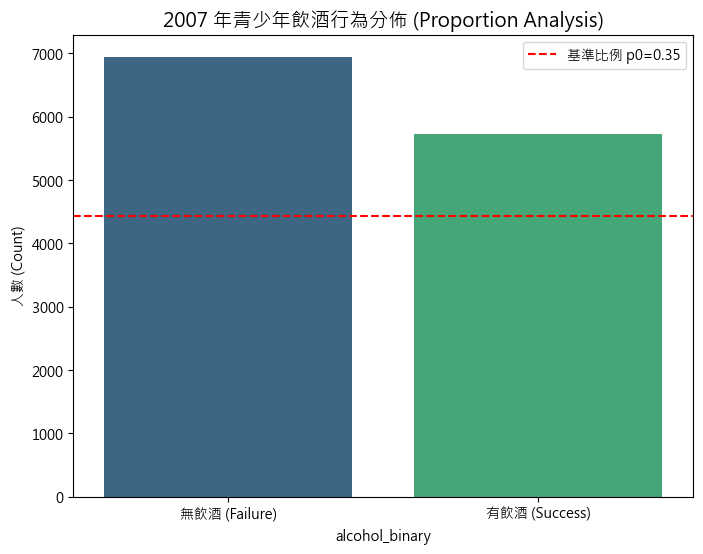

In [10]:
# --- 5. Substantial EDA (圖表) ---
plt.figure(figsize=(8, 6))
# 繪製長條圖，x 軸為 0 (無飲酒) 與 1 (有飲酒)
sns.countplot(x='alcohol_binary', data=df_alc, hue='alcohol_binary', palette='viridis', legend=False)

# 畫出一條紅色的虛線，代表老師給的基準值 0.35 (即 n * 0.35)
plt.axhline(y=len(df_alc) * 0.35, color='red', linestyle='--', label='基準比例 p0=0.35')

plt.title('2007 年青少年飲酒行為分佈 (Proportion Analysis)', fontsize=14)
plt.xticks([0, 1], ['無飲酒 (Failure)', '有飲酒 (Success)'])
plt.ylabel('人數 (Count)')
plt.legend()

# 這一行非常重要：它會把圖表實體化存進你的資料夾
plt.savefig('../outputs/figures/alcohol_proportion_eda.png')
plt.show()

In [9]:
# --- 1, 3, 4. 統計分析 (Z-test & Confidence Interval) ---
count_alc = df_alc['alcohol_binary'].sum()
n_alc = len(df_alc)
p_hat_alc = count_alc / n_alc
z_stat, p_val_alc = proportions_ztest(count_alc, n_alc, value=0.35)
ci_low_alc, ci_upp_alc = proportion_confint(count_alc, n_alc, alpha=0.05, method='normal')

# --- 輸出結果 (優化顯示與解釋) ---
print("-" * 40)
print(f"【母體比例分析結果 - 酒精使用行為】")
print(f"有效樣本數 (n): {n_alc}")
print(f"樣本比例 (p-hat): {p_hat_alc:.4f} (即 {p_hat_alc*100:.2f}%)")
print(f"Z 統計量: {z_stat:.4f}")

# 處理極小的 P 值，讓它顯示為 0.0000 而不是科學記號
if p_val_alc < 0.0001:
    print(f"P 值: < 0.0001 (極度顯著)")
else:
    print(f"P 值: {p_val_alc:.4f}")

print(f"95% 信賴區間: [{ci_low_alc:.4f}, {ci_upp_alc:.4f}]")
print("-" * 40)

# 自動化解釋（對應任務 6）
sig = "存在 [顯著] 差異" if p_val_alc < 0.05 else "無顯著差異"
direction = "顯著高於" if p_hat_alc > 0.35 else "顯著低於"
print(f"結論：由於 P 值 < 0.05，我們拒絕虛無假設。")
print(f"這代表 2007 年青少年的飲酒比例與基準值 0.35 {sig}，且{direction}基準值。")

----------------------------------------
【母體比例分析結果 - 酒精使用行為】
有效樣本數 (n): 12669
樣本比例 (p-hat): 0.4517 (即 45.17%)
Z 統計量: 23.0088
P 值: < 0.0001 (極度顯著)
95% 信賴區間: [0.4431, 0.4604]
----------------------------------------
結論：由於 P 值 < 0.05，我們拒絕虛無假設。
這代表 2007 年青少年的飲酒比例與基準值 0.35 存在 [顯著] 差異，且顯著高於基準值。


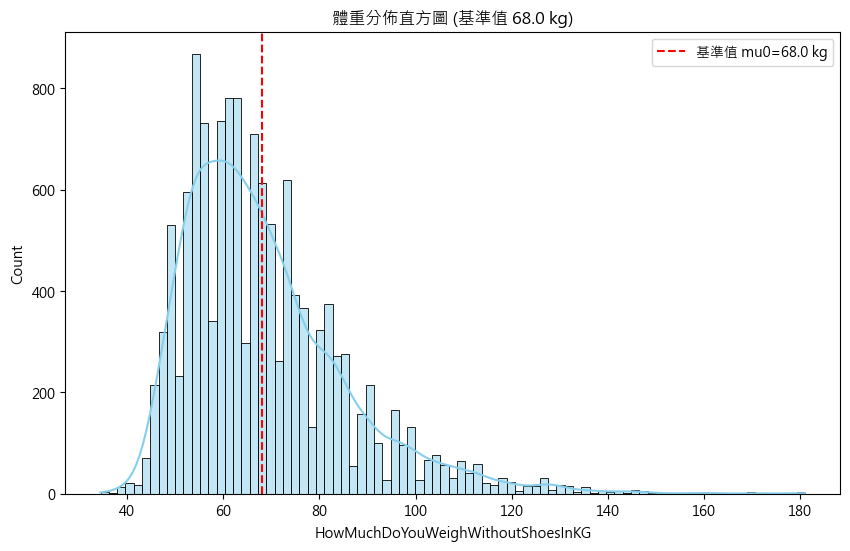

平均數分析結果：P值 = 0.0002, 95% CI = [68.26, 68.84]


In [4]:
# --- 5. Substantial EDA (資料檢查與清理) ---
df_weight = df.dropna(subset=['HowMuchDoYouWeighWithoutShoesInKG']).copy()
weights = df_weight['HowMuchDoYouWeighWithoutShoesInKG']

# --- 5. Substantial EDA (繪圖) ---
plt.figure(figsize=(10, 6))
sns.histplot(weights, kde=True, color='skyblue')
plt.axvline(x=68.0, color='red', linestyle='--', label='基準值 mu0=68.0 kg')
plt.title('體重分佈直方圖 (基準值 68.0 kg)')
plt.legend()
plt.savefig('../outputs/figures/weight_eda.png')
plt.show()

# --- 2 & 4. One-sample test (T-test) ---
t_stat, p_val_m = stats.ttest_1samp(weights, popmean=68.0)

# --- 3. Confidence Interval ---
ci_low_m, ci_upp_m = stats.t.interval(0.95, df=len(weights)-1, loc=weights.mean(), scale=stats.sem(weights))

print(f"平均數分析結果：P值 = {p_val_m:.4f}, 95% CI = [{ci_low_m:.2f}, {ci_upp_m:.2f}]")

In [5]:
# 建立摘要表並存檔
summary = pd.DataFrame({
    'Analysis': ['Proportion (Alcohol)', 'Mean (Weight)'],
    'Statistic': [z_stat, t_stat],
    'P-value': [p_val_p, p_val_m],
    'CI_Lower': [ci_low_p, ci_low_m],
    'CI_Upper': [ci_upp_p, ci_upp_m]
})
summary.to_csv('../outputs/tables/final_summary.csv', index=False)